# BLP
Modified from the Julia code provided by Matteo Courthoud: https://matteocourthoud.github.io/course/empirical-io/12_blp_1995/

Recall BLP using a random-coefficients logit demand. 

## Model
Assume consumers $i\in \{1,..., I\}$ derive utility $u$ from good $j\in \{1,...,J \} in market $t\in \{1,...,T \}:

$$
u_{ijt}=x_{jt}\beta_{it}-\alpha p_{jt}+\xi_{jt}+\varepsilon_{ijt}
$$

where 

- $\xi_{jt}$ is type-1 exteme value (logit) distributed
- $\beta_{it}$ has dimension $K$ (for $K$ product characteristics)

$$
\beta_{it}^k = \beta_0^k + \sigma_k \zeta_{it}^k
$$

and 

- $\beta_0^k$ is a fixed taste for characteristic $k$
- $\zeta_{it}^k$ is random taste, i.i.d. across consumers $i$ and markets $t$

### Setup
$J$ firms and $K$ product characteristics



In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

I = 100 # Number of consumers
J = 10 # firms
K = 2 # product chars
n_markets = 100 # number of markets
#T = 100 # number of markets
beta = np.array([.5, .2, -1]) # preferences
varZeta = 5 # variance of random taste zeta
minJ = 2 # min number of firms per market
maxJ = 6 # max number of firms per market
rangeJ = [minJ, maxJ]
varX = 1 # variance of X
varXi = 2 # variance of Xi

### Demand
Integrate over the individual shocks $\zeta$

In [2]:
def demand(p, X, beta, xi, zeta):
    '''
    Compute demand
    '''
    # Stack characteristics and price
    Xp = np.column_stack((X, p))

    # With random coef, each consumer gets beta + zeta 
    coef = beta[:, None] + zeta 

    # Mean value of utilities
    delta = Xp @ coef 

    # Mean value of outside option
    delta0 = np.zeros((1, zeta.shape[1]))

    # Stack mean values and add shocks -- utilities
    u = np.vstack((delta, delta0)) + xi 

    # Take exponential
    e = np.exp(u) 

    probs = e / e.sum(axis =0, keepdims = True)
    q= probs.mean(axis=1)

    return q[:-1], q[-1]

# Supply
Compute profits given the indivvidual shocks $\zeta$

In [3]:
def pi(p, c, X, beta, xi, zeta):
    q, q0 = demand(p, X, beta, xi, zeta)
    return (p - c) * q

# Next compute profits given price of firm j
def pi_j(pj, j, p, c, X, beta, xi, zeta):
    p = p.copy()
    p[j] = pj # price of firm j
    pr = pi(p, c, X, beta, xi, zeta)
    return pr[j]

# Equilibrium
Given supply and demand, we can compute the equilibrium of a given market. 

In [22]:
def equilibrium(c, X, beta, xi, zeta):
    p = 2.0 * c
    dist = 1
    iteration = 0
    while (dist > 1e-8) and (iteration < 1000):
        p_old = p.copy()
        for j in range(len(p)):
            def obj_fun(pj, j=j):
                return -pi_j(pj[0], j, p, c, X, beta, xi, zeta)
            res = minimize(obj_fun, np.array([1.0]), method='L-BFGS-B')
            p[j] = res.x[0]
        dist = np.max(np.abs(p - p_old))
        iteration += 1
    print(f"    eq converged in {iteration} iters, dist={dist:.2e}")   # <-- ADD THIS
    return p

# Data Simulation
Next, we will need to simulate some market data. 

In [5]:
def draw_data(I, J, K, rangeJ, varXi, varX, varZeta):
    """Draw data for one market"""
    J_ = np.random.randint(rangeJ[0], rangeJ[1] + 1)          # Number of firms (products)
    X_ = np.random.exponential(varX, (J_, K))                 # Product characteristics
    Xi_ = np.random.normal(0, varXi, (J_ + 1, I))             # Product-level utility shocks
    # Consumer-product-level preference shocks
    Zeta_ = np.vstack([np.random.normal(0, 1, (1, I)) * varZeta,
                       np.zeros((K, I))])
    w_ = np.random.uniform(0, 1, J_)                          # Cost shifters
    omega_ = np.random.uniform(0, 1, J_)                      # Cost shocks
    c_ = w_ + omega_                                          # Cost
    j_ = np.sort(np.random.choice(np.arange(1, J + 1), J_, replace=False))  # Subset of firms
    return X_, Xi_, Zeta_, w_, c_, j_

In [21]:
def compute_eq(I, J, beta, rangeJ, varXi, varX, varZeta):
    # Initialize variables
    K = beta.shape[0]-1
    X_, xi_, zeta_, w_, c_, j_ = draw_data(I, J, K, rangeJ, varXi, varX, varZeta)

    # Compute the equilibrium
    p_ = equilibrium(c_, X_, beta, xi_, zeta_)
    print(f"  market with {len(p_)} firms done")
    q_, q0 = demand(p_, X_, beta, xi_, zeta_)
    pr_ = (p_ - c_) * q_ 

    # Save data 
    q0_ = np.ones(len(j_)) * q0 
    df = pd.DataFrame({"j": j_, "w": w_, "p": p_, "q": q_, "q0": q0_, "pr": pr_})
    for k in range(K):
        df[f"x{k+1}"] = X_[:, k]
        df[f"z{k+1}"] = X_[:, k].sum() - X_[:, k]

    return df

Repeat this process for $M$ markets.

In [19]:
def sim_data(I, J, beta, T, rangeJ, varXi, varX, varZeta):
    df = compute_eq(I, J, beta, rangeJ, varXi, varX, varZeta)
    df['t'] = 1
    for t in range(2, T+1):
        df_temp  = compute_eq(I, J, beta, rangeJ, varXi, varX, varZeta)
        df_temp['t'] = t 
        df = pd.concat([df, df_temp], ignore_index = True)
    df.to_csv("../blp.csv", index = False)
    return df

Now all of the prequisites for simulation of data are done. Let's actually simulate the data, and view it. 

* Takes a bit long to run, so I suggest only running this once!

In [23]:
np.random.seed(1995)
df = sim_data(I, J, beta, n_markets, rangeJ, varXi, varX, varZeta)

    eq converged in 1000 iters, dist=9.46e-08
  market with 6 firms done
    eq converged in 1000 iters, dist=1.08e-06
  market with 4 firms done
    eq converged in 1000 iters, dist=3.70e-06
  market with 2 firms done
    eq converged in 1000 iters, dist=1.95e-07
  market with 2 firms done
    eq converged in 1000 iters, dist=1.50e-06
  market with 5 firms done
    eq converged in 1000 iters, dist=6.84e-07
  market with 6 firms done
    eq converged in 1000 iters, dist=3.56e-07
  market with 5 firms done
    eq converged in 1000 iters, dist=4.37e-07
  market with 4 firms done
    eq converged in 1000 iters, dist=2.03e-07
  market with 6 firms done
    eq converged in 1000 iters, dist=9.26e-07
  market with 4 firms done
    eq converged in 1000 iters, dist=2.24e-06
  market with 6 firms done
    eq converged in 1000 iters, dist=3.90e-07
  market with 6 firms done
    eq converged in 1000 iters, dist=1.10e-06
  market with 2 firms done
    eq converged in 1000 iters, dist=1.36e-07
  mar

In [30]:
# Read and preview data
df = pd.read_csv('../blp.csv')
df.head(5)

,j,w,p,q,q0,pr,x1,z1,x2,z2,t
0,3,0.321188,4.082978,0.214991,0.344773,0.732915,2.280325,4.720871,0.638433,3.531600,1
1,4,0.094599,2.853479,0.060251,0.344773,0.110346,0.066648,6.934548,0.182368,3.987665,1
2,5,0.796074,2.896192,0.105599,0.344773,0.219788,1.692412,5.308783,0.029052,4.140982,1
3,6,0.811773,3.064815,0.107735,0.344773,0.196196,1.660799,5.340396,2.699375,1.470659,1
4,8,0.371434,2.758732,0.078057,0.344773,0.128267,1.296367,5.704828,0.603451,3.566582,1


# Estimation
Now that the data have been generated, we can finally get to what we really care about here: the BLP estimation procedure. We first need to compute the shares implied by a specific vector of $\delta\text{s}$ (mean utilities): 

In [26]:
def implied_shares(Xt_, zetat_, deltat_, delta0): 
    u = np.vstack((deltat_[:, None] + Xt_ @ zetat_, delta0))
    e = np.exp(u)
    q = np.mean(e / np.sum(e, axis = 0, keepdims = True), axis = 1) 
    return q[:-1]


## Inner loop
Given the shares, we can compute the inner loop and invert the demand function from shares $q$ to $\delta\text{s}$ 

In [27]:
def inner_loop(qt_, Xt_, zetat_):
    deltat_ = np.ones(qt_.shape)
    delta0 = np.zeros((1, zetat_.shape[1]))
    dist = 1

    while (dist > 1e-8):
        q = implied_shares(Xt_, zetat_, deltat_, delta0)
        deltat2_ = deltat_ + np.log(qt_) - np.log(q)
        dist = np.max(np.abs(deltat2_ - deltat_))
        deltat_ = deltat2_ 
    
    return deltat_

Next, we repeat the inversion for every market to get the vector of mean utilities $\delta$ from the observed market shares $q$.

In [12]:
def compute_delta(q_, X_, zeta_, T):
    delta_ = np.zeros(T.shape)

    # Loop over each market 
    for t in np.unique(T):
        qt_ = q_[T==t]
        Xt_ = X_[T==t]
        delta_[T==t] = inner_loop(qt_, Xt_, zeta_)
    return delta_

With the $\delta\text{s}$ obtained, we can compute $\xi$. To do so, run an IV regression of mean utilies on prices and product characteristics, and obtain the residuals $\xi$. 

In [34]:
def compute_xi(X_, IV_, delta_):
    beta_ = np.linalg.solve(IV_.T @ X_, IV_.T @ delta_)   # both args inside solve()
    xi_ = delta_ - X_ @ beta_
    return xi_, beta_

### Objective function
We can now set up the GMM objective function.

In [14]:
def GMM(varZeta_):
    """Compute GMM objective function"""
    delta_ = compute_delta(q_, X_, zeta_ * varZeta_, T)   # Compute deltas
    xi_, beta_ = compute_xi(X_, IV_, delta_)              # Compute residuals
    gmm = (xi_ @ Z_ @ Z_.T @ xi_) / len(xi_)**2           # Compute orthogonality condition
    return gmm, beta_

And now we can move to estimation (almost)

In [29]:
T = df["t"].astype(int).to_numpy()
X_ = df[["x1", "x2", "p"]].to_numpy()
q_ = df["q"].to_numpy()
q0_ = df["q0"].to_numpy()
IV_ = df[["x1", "x2", "w"]].to_numpy()
Z_ = df[["x1", "x2", "z1", "z2"]].to_numpy()

In [32]:
# Compute logit estimates for comparsion
y = np.log(q_) - np.log(q0_)
beta_logit = np.linalg.inv(IV_.T @ X_) @ (IV_.T @ y)

print(f'Estimated logit coefficients are {beta_logit}')
print(f'True parameter vector is {beta}')

Estimated logit coefficients are [ 2.4455733  -0.09944033 -0.90678877]
True parameter vector is [ 0.5  0.2 -1. ]


The estimates logit coefficients do not capture the true parameters well. What about BLP? 

In [36]:
# Draw shocks
zeta_ = np.vstack((np.random.normal(0, 1, (1, I)), np.zeros((K, I))))

# Minimize GMM objective function
res = minimize(lambda x: GMM(x[0])[0], np.array([2.0]), method='L-BFGS-B')
varZeta_ = res.x[0]
beta_blp = GMM(varZeta_)[1]
print(f"Estimated BLP coefficients: {beta_blp}")
print(f'True parameter vector is {beta}')

Estimated BLP coefficients: [ 0.66138549  0.09945126 -0.57166061]
True parameter vector is [ 0.5  0.2 -1. ]


Considering the small sample (400 observations), the BLP procedure recovers the true parameters reasonably well: the estimated coefficients have the correct signs and magnitudes close to the truth, and the price coefficient in particular is far better identified than the naive logit estimate.

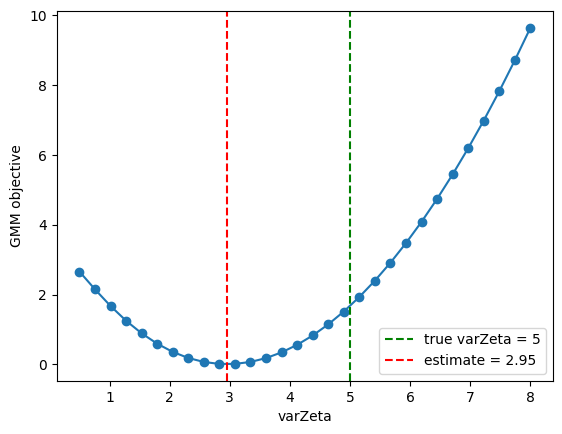

In [39]:
import matplotlib.pyplot as plt

grid = np.linspace(0.5, 8, 30)
vals = [GMM(v)[0] for v in grid]

plt.plot(grid, vals, marker='o')
plt.axvline(5, color='green', linestyle='--', label='true varZeta = 5')
plt.axvline(varZeta_, color='red', linestyle='--', label=f'estimate = {varZeta_:.2f}')
plt.xlabel('varZeta')
plt.ylabel('GMM objective')
plt.legend()
plt.show()

The plot above shows the GMM objective as a function of ζ's scale, with a clear, well-defined minimum near 2.95 — somewhat below the true value of 5. That gap reflects simulation error rather than a failure of the method: with only I = 100 simulated consumers, the finite Monte Carlo approximation of the market-share integral pulls the estimated scale below its true value.

If we wanted to 'do better', we might consider redrawing $\zeta$ with more consumers (larger $I$), which would reduce the simulation error that biases the estimates toward smaller values. However, the goal of this exercise was to get a Python implementation of the general BLP estimation procedure working, and so redrawing $\zeta$ is outside of this exercise's scope -- at this stage it is purely a matter of computational cost, not a limitation of the method. 